# Decoded Plots

In [41]:
import pandas as pd
from pathlib import Path

csv_path = Path("../output/decoded.csv")
df = pd.read_csv(csv_path)

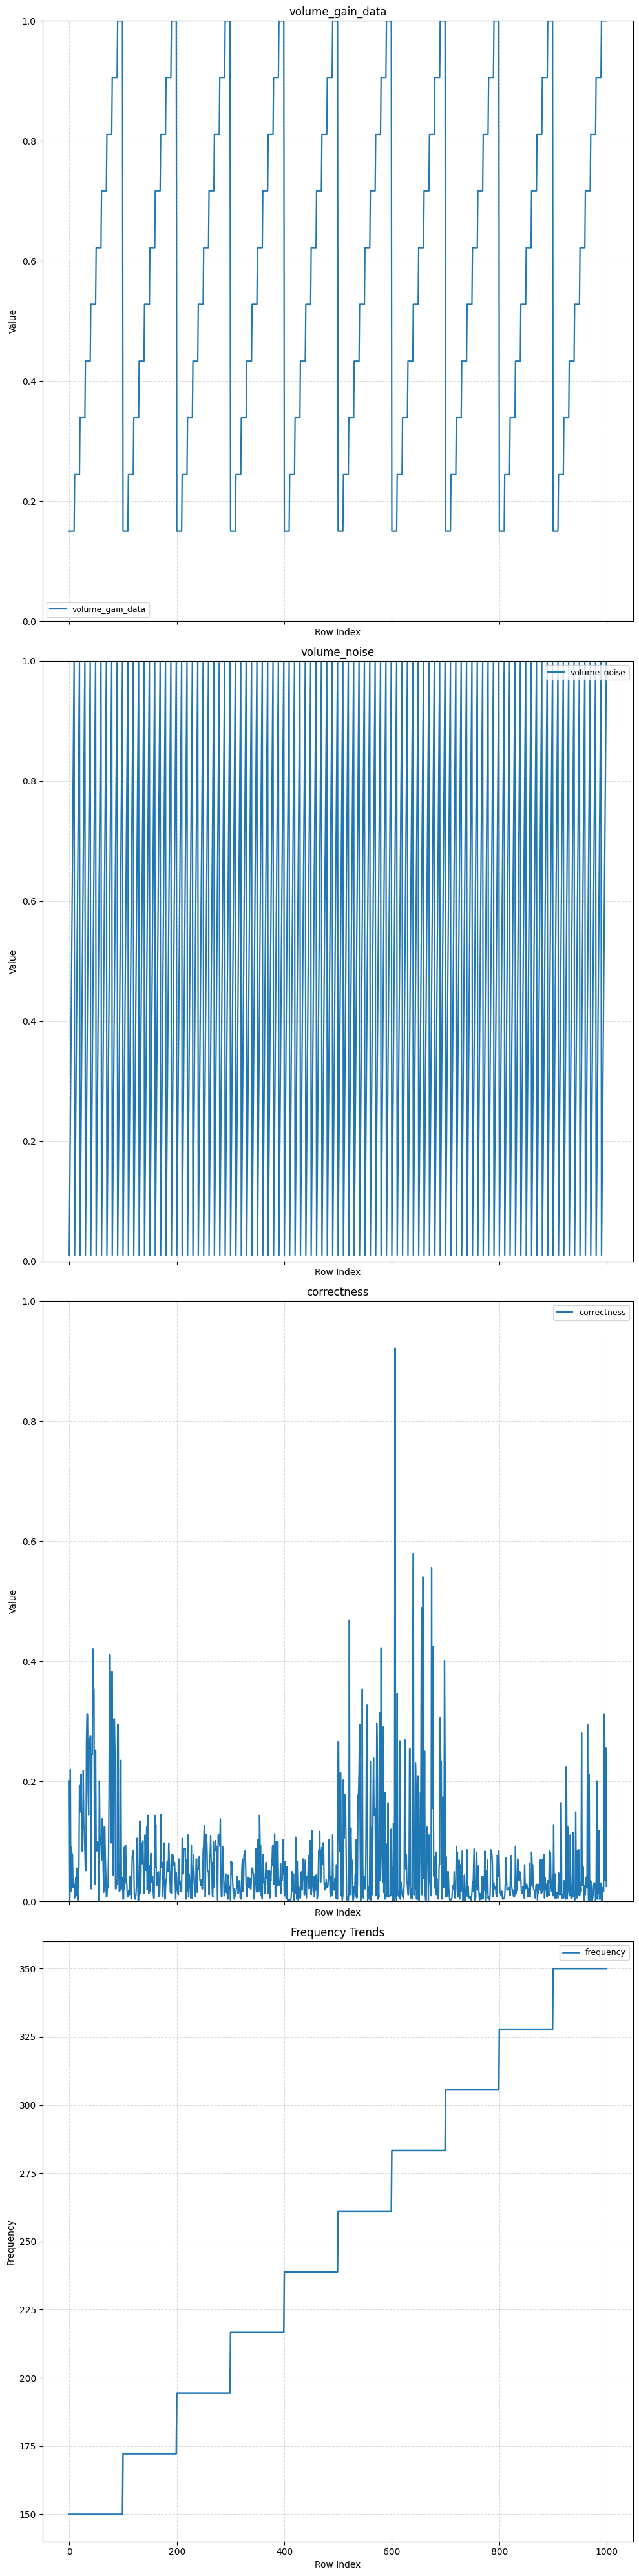

In [42]:
import matplotlib.pyplot as plt
from IPython.display import SVG, display
from pathlib import Path

# Build line charts directly from decoded.csv data loaded into df
numeric_df = df.select_dtypes(include="number")

if numeric_df.empty:
    raise ValueError("decoded.csv has no numeric columns to plot.")

vars_cols = [
    numeric_df.volume_gain_data,
    numeric_df.volume_noise,
    numeric_df.correctness,
]

# Create a subplot for each column in vars_cols + frequency
fig, axes = plt.subplots(4, 1, figsize=(10, 10*4), sharex=True)

# Plot each column in vars_cols in its own subplot
for idx, col in enumerate(vars_cols):
    ax = axes[idx]
    ax.plot(numeric_df.index, col, linewidth=1.6, label=col.name)
    ax.set_title(f"{col.name}")
    ax.set_ylabel("Value")
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.legend(loc="best", fontsize=9)

# Plot frequency in the 4th subplot
ax4 = axes[3]
ax4.plot(
    numeric_df.index,
    numeric_df.frequency,
    linewidth=1.8,
    label=numeric_df.frequency.name,
)
ax4.set_title("Frequency Trends")
ax4.set_xlabel("Row Index")
ax4.set_ylabel("Frequency")
ax4.grid(True, linestyle="--", alpha=0.45)
ax4.legend(loc="best", fontsize=9)

# Set xlabel for all plots
for ax in axes:
    ax.set_xlabel("Row Index")

plt.tight_layout()

# Save and display as SVG
svg_path = Path("../output/decoded_numeric_trends.svg")
fig.savefig(svg_path, format="svg", bbox_inches="tight")